In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

In [36]:
N_particles = 500

mpl.rcParams.update({
    # Font (gnuplot ≈ Helvetica)
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],

    # Dimensioni testo
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,

    # Linee
    "lines.linewidth": 1.8,

    # Assi
    "axes.linewidth": 1.0,

    # Griglia (stile gnuplot)
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,

    # Legenda
    "legend.frameon": True,
    "legend.fancybox": False,
    "legend.framealpha": 1.0,
    "legend.edgecolor": "black",
    "legend.facecolor": "white"
})

In [37]:
def pot_neg(x,lamb):
    return np.pow(x,-12) - np.pow(x,-6) - lamb/x

def pot_pos(x,lamb):
    return np.pow(x,-12) - np.pow(x,-6) + lamb/x

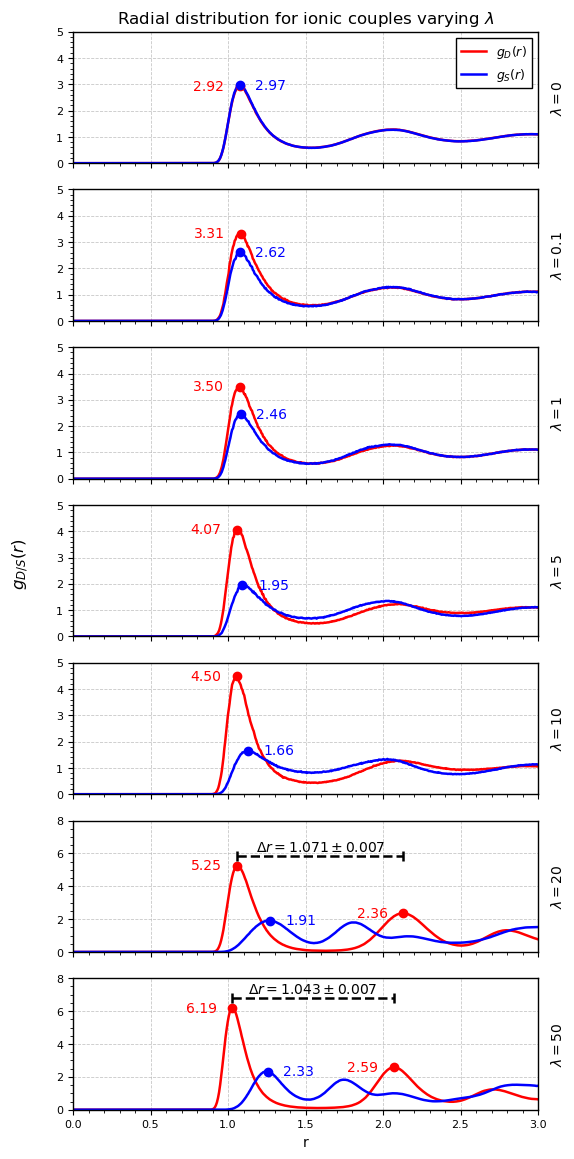

In [ ]:
max_r_differ_array = []
max_g_differ_array = []

max_r_same_array = []
max_g_same_array = []

# 40%, 43%, 43%, 0.42%, 0.41%, 66%, 48%
lamb = [0, 0.1, 1,5,10,20,50]
n_lamb = np.size(lamb)

x = np.linspace(0.1,4,10000)

fig, axes = plt.subplots(n_lamb, 1, figsize=(6, 2*n_lamb),sharex=True)
fig.subplots_adjust(hspace=0.2) 

axes[0].set_title(r'Radial distribution for ionic couples varying $\lambda$')

for i in range(0,n_lamb):
    l = lamb[i]
    y = pot_neg(x,l)
    y_2 = pot_pos(x,l)

    data_differ = np.loadtxt(f"./lambda{l}/radial_distribution_differ.csv", delimiter=";")
    axes[i].plot(data_differ[:,0], data_differ[:,1],c="red", label=r"$g_D(r)$")

    idx = np.argmax(data_differ[:, 1])
    row_max = data_differ[idx]

    x_max_diff = data_differ[idx, 0]
    y_max_diff = data_differ[idx, 1]
    max_r_differ_array.append(x_max_diff)
    max_g_differ_array.append(y_max_diff)

    data_same = np.loadtxt(f"./lambda{l}/radial_distribution_equal.csv", delimiter=";")
    axes[i].plot(data_same[:,0], data_same[:,1],c="blue", label =r"$g_S(r)$")

    idx = np.argmax(data_same[:, 1])
    row_max = data_same[idx]

    x_max_same = data_same[idx, 0]
    y_max_same = data_same[idx, 1]
    max_r_same_array.append(x_max_same)
    max_g_same_array.append(y_max_same)

    axes[i].text(
        x_max_diff - 0.3, y_max_diff,
        f'{y_max_diff:.2f}',
        va='center',
        ha='left',
        color="red"
    )
    axes[i].plot(x_max_diff, y_max_diff, "o",color="red")

    axes[i].text(
        x_max_same + 0.1, y_max_same,
        f'{y_max_same:.2f}',
        va='center',
        ha='left',
        color="blue"
    )
    axes[i].plot(x_max_same, y_max_same, "o",color="blue")

    axes[i].text(
        1.025, 0.5,
        rf'$\lambda = {l}$',
        transform=axes[i].transAxes,
        rotation=90,
        va='center',
        ha='left'
    )

    axes[i].set_xlim([0,3])
    axes[i].set_ylim([0,5])

    if i != n_lamb-1:
        axes[i].tick_params(axis='x', labelbottom=False)
    
    if i == n_lamb-1:
        axes[i].set_xlabel("r")

    if l >= 20:
        axes[i].set_ylim([0,8])

        # For last two plot the second maximum
        idx = np.argmax(data_differ[190:, 1]) + 190
        row_max = data_differ[idx]

        x_max_diff2 = data_differ[idx, 0]
        y_max_diff2 = data_differ[idx, 1]

        axes[i].text(
            x_max_diff2 - 0.3, y_max_diff2,
            f'{y_max_diff2:.2f}',
            va='center',
            ha='left',
            color="red"
        )
        axes[i].plot(x_max_diff2, y_max_diff2, "o",color="red")

        delta_x = x_max_diff2 - x_max_diff
        
        y_line = max(y_max_diff, y_max_diff2) + 0.6

        axes[i].hlines(
            y=y_line,
            xmin=x_max_diff,
            xmax=x_max_diff2,
            colors='black',
            linestyles='--'
        )

        axes[i].text(
            (x_max_diff + x_max_diff2) / 2,
            y_line + 0.1,
            rf'$\Delta r = {delta_x:.3f}\pm0.007$',
            ha='center',
            va='bottom'
        )

        cap_height = 0.3
        axes[i].vlines(
            x=[x_max_diff, x_max_diff2],
            ymin=y_line - cap_height,
            ymax=y_line + cap_height,
            colors='black'
        )

    if l == 100:
        axes[i].set_ylim([0,10])

    if i == 0:
        axes[i].legend(loc='upper right')

    axes[i].xaxis.minorticks_on()
    axes[i].yaxis.minorticks_on()
    
    #axes[i].set_ylabel("g(r)")
    axes[i].grid()

fig.supylabel(r"$g_{D/S}(r)$") # ylabel in common

plt.savefig("lambda_coupling.pdf", bbox_inches="tight")
plt.show()



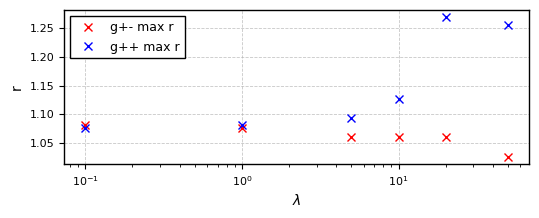

In [39]:
fig = plt.figure(figsize=(6,2))

plt.plot(lamb,max_r_differ_array,"x", label="g+- max r",c="red")
plt.plot(lamb,max_r_same_array, "x",label="g++ max r",c="blue")

plt.xscale("log")
plt.grid()
plt.xlabel(r"$\lambda$")
plt.ylabel("r")
plt.legend()
plt.show()

In [40]:
def autocorrelation_time(data, max_lag=None):

    data = np.asarray(data)
    N = len(data)

    if max_lag is None:
        max_lag = N // 2

    mean = np.mean(data)
    var = np.var(data)

    if var == 0:
        return 0.0

    autocorr = []

    for t in range(max_lag):
        c = np.mean((data[:N - t] - mean) * (data[t:] - mean)) / var
        autocorr.append(c)

    autocorr = np.array(autocorr)

    # sum until autocorrelation is positive
    positive = autocorr[1:][autocorr[1:] > 0]

    tau = 0.5 + np.sum(positive)
    return tau

tau: 291.1307469967742, -6.030787013516621 pm 0.006276489444286044, N eff = 42.93431775565258
tau: 74.17378896238463, -6.015640637984502 pm 0.006704642531584738, N eff = 67.40251603616164
tau: 72.51455576695557, -6.546071992208595 pm 0.006878394347306595, N eff = 68.94477870163333
tau: 158.38774458941356, -9.194705133578983 pm 0.011143202998623198, N eff = 31.564942180091883
tau: 124.90856684714058, -12.738272734711755 pm 0.010092174379609846, N eff = 40.02527709823331
tau: 123.52937350949009, -17.505356606102005 pm 0.005391650020845275, N eff = 60.71025689629887
tau: 316.55001176494335, -35.39320757463178 pm 0.00949586877085291, N eff = 23.691359094211034


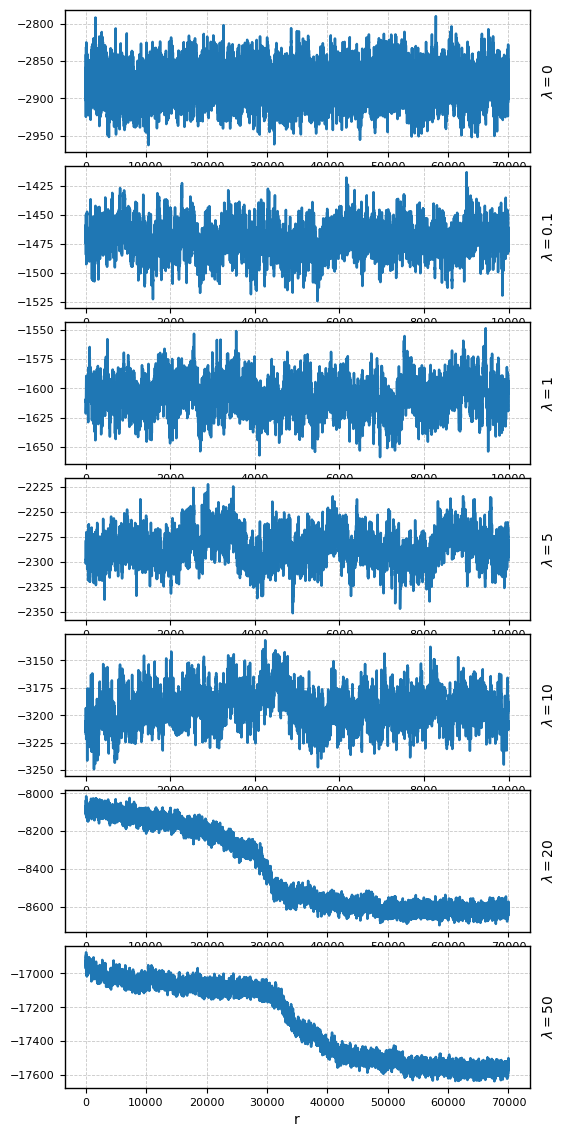

In [52]:
fig, axes = plt.subplots(n_lamb, 1, figsize=(6, 2*n_lamb))
fig.subplots_adjust(hspace=0.1) 

E_mean = []
E_std = []

for i in range(0,n_lamb):
    l = lamb[i]
    
    data_en = np.loadtxt(f"./lambda{l}/energy.csv", delimiter=";")
    energy_data = 0
    
    if(l <= 10 and l != 0):
        energy_data = (data_en[5000:] - 6.828018E+01)/256
    elif(l == 0):
        energy_data = (data_en[50000:] - 1.333597E+02)/500
    else:
        energy_data = (data_en[60000:]- 1.333597E+02)/500
    
    tau = autocorrelation_time(energy_data)

    print(f"tau: {tau}, {np.mean(energy_data)} pm {np.std(energy_data)*np.sqrt(2*tau/np.size(energy_data))}, N eff = {np.size(energy_data)/(2*tau)}")


    axes[i].plot(data_en[5000:])

    axes[i].text(
        1.025, 0.5,
        rf'$\lambda = {l}$',
        transform=axes[i].transAxes,
        rotation=90,
        va='center',
        ha='left'
    )
    
    if i == n_lamb-1:
        axes[i].set_xlabel("r")

    axes[i].grid()
    
plt.show()


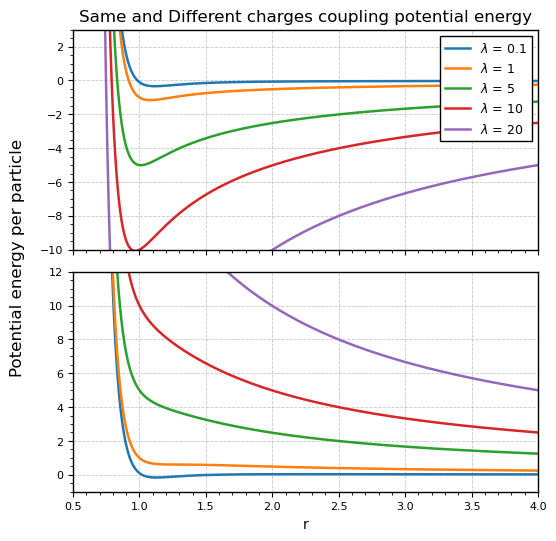

In [ ]:

x = np.linspace(0.1,4,10000)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
fig.subplots_adjust(hspace=0.1) 

for l in lamb[1:-1]:
    y_1 = pot_neg(x,l)
    axes[0].plot(x,y_1,label=fr"$\lambda$ = {l}")

axes[0].legend()
axes[0].set_ylim([-10,3])
axes[0].set_xlim([0.5,4])
axes[0].tick_params(axis='x', labelbottom=False)
axes[0].legend(loc='upper right')

for l in lamb[1:-1]:
    y_2 = pot_pos(x,l)
    axes[1].plot(x,y_2)

axes[1].set_ylim([-1,12])
axes[1].set_xlim([0.5,4])

axes[1].grid()
axes[0].grid()

fig.supylabel(r"Potential energy per particle") # ylabel in common

axes[1].set_xlabel("r")

axes[0].xaxis.minorticks_on()
axes[0].yaxis.minorticks_on()

axes[1].xaxis.minorticks_on()
axes[1].yaxis.minorticks_on()
axes[0].set_title("Same and Different charges coupling potential energy")

plt.savefig("coupling_potential.pdf", bbox_inches="tight")
plt.show()

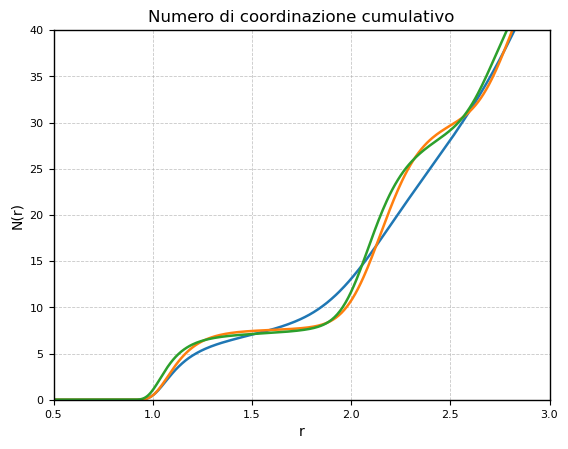

In [ ]:
import pandas as pd

plt.figure()

rho_tot = 0.85        # densità totale
x_species = 0.5       # frazione della specie (0.5 se miscela equimolare)
rho = rho_tot * x_species   # densità della specie opposta

for l in [10,20,50]:
    data = pd.read_csv(f"./lambda{l}/radial_distribution_differ.csv",sep=";")

    r = data.iloc[:, 0].values      # prima colonna: r
    g = data.iloc[:, 1].values      # seconda colonna: g(r)

    # =========================
    # CALCOLO DI N(r)
    # =========================
    integrand = g * r**2
    dr = np.diff(r)

    # integrazione cumulativa (trapezi)
    N_tilde = np.zeros_like(r)
    N_tilde[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dr)

    # numero di coordinazione vero
    N_r = 4 * np.pi * rho * N_tilde
    plt.plot(r, N_r)


plt.xlabel("r")
plt.ylabel("N(r)")
plt.title("Numero di coordinazione cumulativo")
plt.grid(True)
plt.xlim([0.5,3])
plt.ylim([0,40])
plt.show()
